In [75]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are
from scipy.signal import cont2discrete
from matplotlib import pyplot as plt

In [76]:
m = 1.2              # kg
g = 9.81             # m/s^2
l = 0.22             # m, arm length
I_x = 0.015          # kg m^2
I_y = 0.015          # kg m^2
I_z = 0.028          # kg m^2
J = np.diag([I_x, I_y, I_z])

c_t = 1.8e-5         # thrust coefficient: T_i = c_t * q_i^2
c_r = 2.5e-7         # yaw drag torque coefficient

q_hover = np.sqrt(m * g / (4 * c_t))
k_drag = 0.18     # quadratic drag coefficient (N / (m/s)^2)
d_ref = 5.0       # target distance ahead at trim (m)
v_shot = 250.     # shooting speed in meters per second

dt_control = 0.02
sim_time = 12.0
lead_fit_window = 50
random_seed = 7
t_predict = 0.1
du_lpf_alpha = 0.28  # low-pass on delta-u to reduce measurement-driven chatter

# LQR cost on full 18-state (only indices 6-17 used by reduced LQR)
#   indices 0-5: P, V (unused)
#   indices 6-8: phi, theta, psi
#   indices 9-11: p, q, r
#   indices 12-14: rho_x, rho_y, rho_z
#   indices 15-17: nu_x, nu_y, nu_z
Q_lqr = np.diag([
    0.0,    0.0,    0.0,
    0.0,    0.0,    0.0,
    500.0,  500.0,  2000.0,
    50.0,   50.0,   200.0,
    1.8e4,  1.2e4,  1.2e4,
    1.2e4,   800.0,  800.0,
])

R_lqr = np.diag([5.0e-3, 5.0e-3, 5.0e-3, 5.0e-3])

Q_integral = np.diag([3.5e4, 1.2e4, 1.2e4])

# Process noise intensity (continuous-time); Q_d = V_kf * dt in the discrete Riccati.
# Keep V << W_meas so the filter trusts the model but still fuses sensors.
V_kf = np.diag([
    1.0e-6, 1.0e-6, 1.0e-6,
    1.0e-6, 1.0e-6, 1.0e-6,
    1.0e-8, 1.0e-8, 1.0e-8,
    1.0e-8, 1.0e-8, 1.0e-8,
    1.0e-7, 1.0e-7, 1.0e-7,
    1.0e-7, 1.0e-7, 1.0e-7,
])

# Only angles, rates, relative pos/vel are "measured" (12 outputs). Avoids injecting
# huge correlated noise into every state via C = I.
W_kf = np.diag([
    1.0e-4, 1.0e-4, 1.0e-4,
    1.5e-3, 1.5e-3, 1.5e-3,
    9.0e-3, 2.5e-2, 2.5e-2,
    2.5e-2, 6.0e-2, 6.0e-2,
])

LQR_STATE_IDX = np.array([6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], dtype=int)

MEAS_IDX = np.arange(6, 18, dtype=int)
C_meas = np.zeros((len(MEAS_IDX), 18))
for i, j in enumerate(MEAS_IDX):
    C_meas[i, j] = 1.0


In [77]:
P0_target = np.array([8.0, 1.5, 0.5])
V0_target = np.array([0.8, -0.2, 0.1])

v_lin = np.linalg.norm(V0_target)

def target_fn(t, x):
    P_F = P0_target + V0_target * t
    V_F = V0_target
    a_F = np.zeros(3)
    return P_F, V_F, a_F

def skew(w):
    p, q, r = w
    return np.array([
        [0.0, -r,   q],
        [r,   0.0, -p],
        [-q,  p,   0.0]
    ])

def R_body_to_world(phi, theta, psi):
    cph, sph = np.cos(phi), np.sin(phi)
    cth, sth = np.cos(theta), np.sin(theta)
    cps, sps = np.cos(psi), np.sin(psi)

    return np.array([
        [cps*cth,  cps*sth*sph - sps*cph,  cps*sth*cph + sps*sph],
        [sps*cth,  sps*sth*sph + cps*cph,  sps*sth*cph - cps*sph],
        [-sth,     cth*sph,                cth*cph]
    ])

def euler_rate_matrix(phi, theta):
    cph, sph = np.cos(phi), np.sin(phi)
    cth = np.cos(theta)
    tth = np.tan(theta)

    return np.array([
        [1.0, sph*tth, cph*tth],
        [0.0, cph,    -sph],
        [0.0, sph/cth, cph/cth]
    ])

# ----------------------------
# Trim helpers for forward flight with quadratic drag
# ----------------------------
def trim_pitch_from_speed(v):
    return np.arctan2(k_drag * v**2, m * g)

def trim_thrust_from_speed(v):
    return np.hypot(m * g, k_drag * v**2)

def trim_u_from_speed(v):
    # u_i = q_i^2, equal on all four rotors at the trim thrust
    return trim_thrust_from_speed(v) / (4 * c_t)

def trim_rotor_speed_from_speed(v):
    return np.sqrt(trim_u_from_speed(v))

# Example rotor input function: hold the trim for v_lin
def rotor_speeds_fn(t, x):
    q0 = trim_rotor_speed_from_speed(v_lin)
    return np.full(4, q0)

# ----------------------------
# Nonlinear 18-state RHS with quadratic drag
# x = [P(3), V(3), angles(3), omega(3), rho(3), nu(3)]
# ----------------------------
def quad_target_rhs(t, x, rotor_speeds_fn, target_fn):
    P = x[0:3]
    V = x[3:6]
    phi, theta, psi = x[6:9]
    omega = x[9:12]
    rho = x[12:15]
    nu = x[15:18]

    R = R_body_to_world(phi, theta, psi)
    E = euler_rate_matrix(phi, theta)

    q_rot = np.asarray(rotor_speeds_fn(t, x), dtype=float)
    u = q_rot**2
    P_F, V_F, a_F = target_fn(t, x)

    T = c_t * np.sum(u)

    tau_phi   = l * c_t * (-u[0] - u[3] + u[1] + u[2])
    tau_theta = l * c_t * ( u[0] + u[1] - u[2] - u[3])
    tau_psi   = c_r * ( u[0] - u[1] + u[2] - u[3])
    tau = np.array([tau_phi, tau_theta, tau_psi])

    e3 = np.array([0.0, 0.0, 1.0])

    # Quadratic drag in world frame: F_drag = -k_drag * ||V|| * V
    Vnorm = np.linalg.norm(V)
    F_drag = -k_drag * Vnorm * V

    P_dot = V
    V_dot = (T / m) * (R @ e3) - g * e3 + F_drag / m

    euler_dot = E @ omega
    omega_dot = np.linalg.solve(J, tau - np.cross(omega, J @ omega))

    Omega = skew(omega)
    rho_dot = nu - Omega @ rho
    nu_dot = -Omega @ nu + R.T @ (a_F - V_dot)

    return np.concatenate([
        P_dot,
        V_dot,
        euler_dot,
        omega_dot,
        rho_dot,
        nu_dot
    ])

In [78]:
def linearized_AB_18(v=v_lin, d=d_ref):
    theta0 = trim_pitch_from_speed(v)
    T0 = trim_thrust_from_speed(v)

    s = np.sin(theta0)
    c = np.cos(theta0)
    sec = 1.0 / c
    tan = np.tan(theta0)

    R0 = R_body_to_world(0.0, theta0, 0.0)
    RT0 = R0.T
    e3 = np.array([0.0, 0.0, 1.0])

    # State indices
    Px, Py, Pz = 0, 1, 2
    Vx, Vy, Vz = 3, 4, 5
    phi, theta, psi = 6, 7, 8
    p, q, r = 9, 10, 11
    rx, ry, rz = 12, 13, 14
    nux, nuy, nuz = 15, 16, 17

    A = np.zeros((18, 18))
    B = np.zeros((18, 4))

    # P_dot = V
    A[Px:Px+3, Vx:Vx+3] = np.eye(3)

    # Drag Jacobian at V* = [v,0,0], v>0:
    # d/dV ( -k ||V|| V / m ) = -(k/m) diag(2v, v, v)
    J_drag = -(k_drag / m) * np.diag([2.0 * v, v, v])

    # d/d(angles) of translational acceleration (T/m) R e3 at trim
    # evaluated at phi=0, theta=theta0, psi=0
    dacc_dangles = np.array([
        [0.0,            (T0 / m) * c,  0.0],
        [-(T0 / m),      0.0,           (T0 / m) * s],
        [0.0,           -(T0 / m) * s,  0.0],
    ])

    # V_dot block
    A[Vx:Vx+3, Vx:Vx+3] = J_drag
    A[Vx:Vx+3, phi:phi+3] = dacc_dangles

    # Input enters V_dot through total thrust only
    thrust_dir = R0 @ e3                      # = [sin(theta0), 0, cos(theta0)]
    B[Vx:Vx+3, :] = (c_t / m) * np.outer(thrust_dir, np.ones(4))

    # Euler kinematics at trim phi=0, theta=theta0
    # [phi_dot, theta_dot, psi_dot]^T = E0 [p,q,r]^T
    E0 = np.array([
        [1.0, 0.0, tan],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, sec],
    ])
    A[phi:phi+3, p:p+3] = E0

    # Rotational dynamics at omega*=0
    B[p, :] = l * c_t * np.array([-1, +1, +1, -1]) / I_x
    B[q, :] = l * c_t * np.array([+1, +1, -1, -1]) / I_y
    B[r, :] = c_r   * np.array([+1, -1, +1, -1]) / I_z

    # rho_dot = nu - omega x rho, with rho* = [d,0,0]
    A[rx:rx+3, nux:nux+3] = np.eye(3)
    A[ry, r] = -d
    A[rz, q] = +d

    # nu_dot = -R0^T * delta(V_dot)   at trim, since nu*=0 and a_F*=0
    A[nux:nux+3, Vx:Vx+3] = -RT0 @ J_drag
    A[nux:nux+3, phi:phi+3] = -RT0 @ dacc_dangles
    B[nux:nux+3, :] = -RT0 @ B[Vx:Vx+3, :]

    # Trim state and input
    x_trim = np.zeros(18)
    x_trim[Vx] = v
    x_trim[theta] = theta0
    x_trim[rx] = d

    u_trim = np.full(4, trim_u_from_speed(v))

    return A, B, x_trim, u_trim

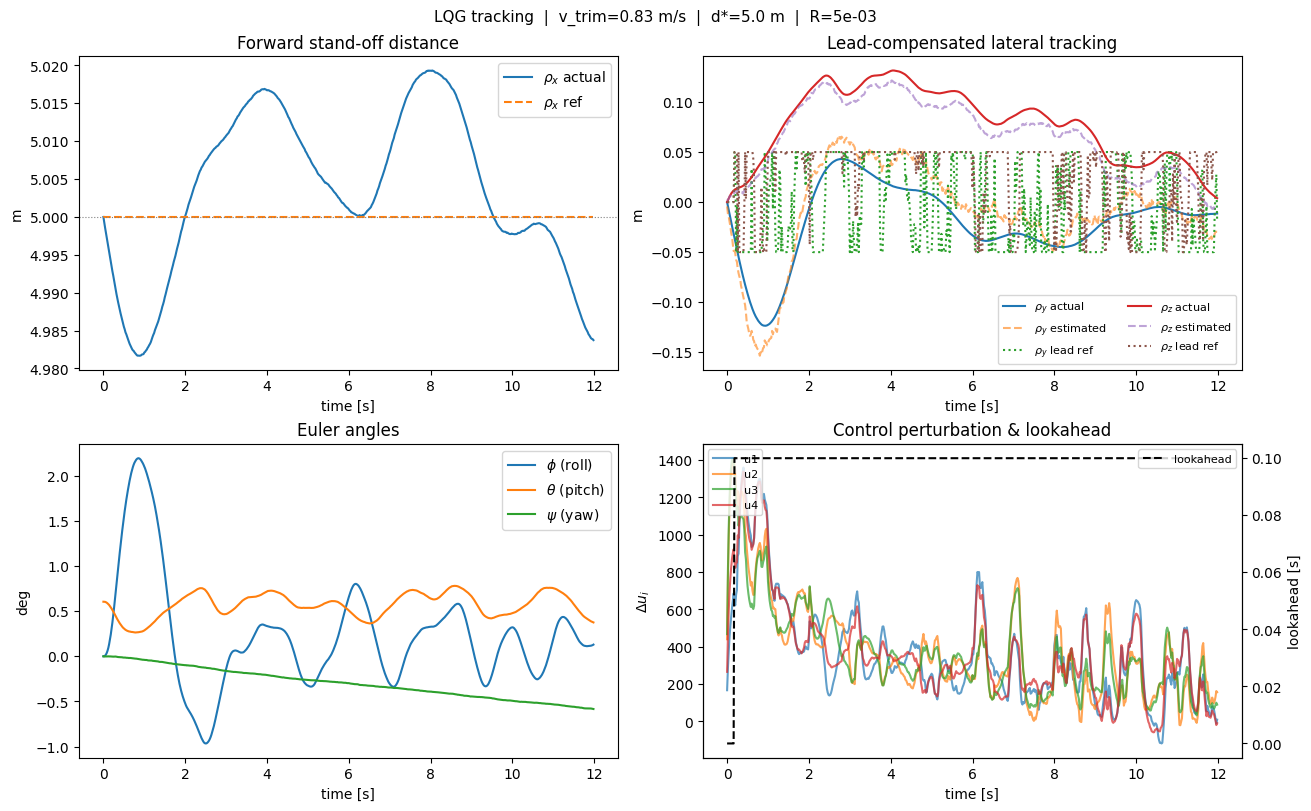

In [79]:
def continuous_lqr_gain(A, B, Q, R, state_idx=None,
                        int_state_idx=None, Q_int=None):
    if state_idx is None:
        state_idx = np.arange(A.shape[0])

    A_red = A[np.ix_(state_idx, state_idx)]
    B_red = B[state_idx, :]
    Q_red = Q[np.ix_(state_idx, state_idx)]
    n_red = len(state_idx)

    if int_state_idx is not None and Q_int is not None:
        state_list = list(state_idx)
        int_pos = [state_list.index(i) for i in int_state_idx]
        n_int = len(int_pos)
        n_aug = n_red + n_int

        A_aug = np.zeros((n_aug, n_aug))
        A_aug[:n_red, :n_red] = A_red
        for k, pos in enumerate(int_pos):
            A_aug[n_red + k, pos] = 1.0

        B_aug = np.zeros((n_aug, B_red.shape[1]))
        B_aug[:n_red, :] = B_red

        Q_aug = np.zeros((n_aug, n_aug))
        Q_aug[:n_red, :n_red] = Q_red
        Q_aug[n_red:, n_red:] = Q_int

        P_aug = solve_continuous_are(A_aug, B_aug, Q_aug, R)
        K_aug = np.linalg.solve(R, B_aug.T @ P_aug)

        K_full = np.zeros((B.shape[1], A.shape[0]))
        K_full[:, state_idx] = K_aug[:, :n_red]
        K_int = K_aug[:, n_red:]
        return K_full, K_int

    P_red = solve_continuous_are(A_red, B_red, Q_red, R)
    K_red = np.linalg.solve(R, B_red.T @ P_red)

    K_full = np.zeros((B.shape[1], A.shape[0]))
    K_full[:, state_idx] = K_red
    return K_full, None


def discrete_kalman_gain_steady(Ad, C, Qd, Rd, n_iter=8000):
    """Steady-state discrete Kalman gain (DARE)."""
    n = Ad.shape[0]
    P = np.eye(n)
    ny = C.shape[0]
    Iy = np.eye(ny)
    for _ in range(n_iter):
        S = C @ P @ C.T + Rd
        P_new = Ad @ P @ Ad.T + Qd - Ad @ P @ C.T @ np.linalg.solve(S, C @ P @ Ad.T)
        if np.linalg.norm(P_new - P, ord="fro") < 1e-12:
            P = P_new
            break
        P = P_new
    S = C @ P @ C.T + Rd
    K = P @ C.T @ np.linalg.solve(S, Iy)
    return K, P


def compute_lqg_gains(v_trim):
    A, B, x_trim, u_trim = linearized_AB_18(v=v_trim, d=d_ref)
    K, K_int = continuous_lqr_gain(
        A, B, Q_lqr, R_lqr,
        state_idx=LQR_STATE_IDX,
        int_state_idx=np.array([12, 13, 14]),
        Q_int=Q_integral,
    )
    D0 = np.zeros((C_meas.shape[0], B.shape[1]))
    Ad, Bd, _, _, _ = cont2discrete((A, B, C_meas, D0), dt_control, method="zoh")
    Qd = V_kf * dt_control
    Kd, _ = discrete_kalman_gain_steady(Ad, C_meas, Qd, W_kf)
    return A, B, K, K_int, Kd, Ad, Bd, x_trim, u_trim


def fit_quadratic_series(times, values):
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)
    n_fit = min(len(times), lead_fit_window)

    if n_fit == 0:
        return np.array([0.0, 0.0, 0.0])
    if n_fit == 1:
        return np.array([0.0, 0.0, values[-1]])

    t_fit = times[-n_fit:] - times[-1]
    y_fit = values[-n_fit:]
    degree = 2 if n_fit >= 3 else 1
    coeffs = np.polyfit(t_fit, y_fit, degree)

    if degree == 1:
        coeffs = np.array([0.0, coeffs[0], coeffs[1]])

    return coeffs


def eval_quadratic(coeffs, tau):
    a2, a1, a0 = coeffs
    pos = a2 * tau**2 + a1 * tau + a0
    vel = 2.0 * a2 * tau + a1
    return pos, vel


def predict_lead_position(times, rho_history):
    rho_hist = np.asarray(rho_history, dtype=float)
    if rho_hist.ndim < 2 or len(rho_hist) < 10:
        return np.array([d_ref, 0.0, 0.0]), 0.0

    coeff_y = fit_quadratic_series(times, rho_hist[:, 1])
    coeff_z = fit_quadratic_series(times, rho_hist[:, 2])

    y_pred, _ = eval_quadratic(coeff_y, t_predict)
    z_pred, _ = eval_quadratic(coeff_z, t_predict)

    max_lead_dev = 0.05
    y_pred = np.clip(y_pred, -max_lead_dev, max_lead_dev)
    z_pred = np.clip(z_pred, -max_lead_dev, max_lead_dev)
    return np.array([d_ref, y_pred, z_pred]), t_predict


def propagate_nonlinear_state(t, x, u_cmd, dt):
    rotor_speeds = np.sqrt(np.clip(u_cmd, 0.0, None))
    rhs = lambda tau, state: quad_target_rhs(
        tau,
        state,
        lambda _tau, _state, rs=rotor_speeds: rs,
        target_fn,
    )
    sol = solve_ivp(rhs, (t, t + dt), x, t_eval=[t + dt], max_step=dt / 4.0)
    return sol.y[:, -1]


def run_lqg_simulation(t_final=sim_time, dt=dt_control):
    sim_rng = np.random.default_rng(random_seed)
    times = np.arange(0.0, t_final, dt)

    _, _, K, K_int, Kd, Ad, Bd, x_trim, u_trim = compute_lqg_gains(v_lin)

    R0 = R_body_to_world(0.0, trim_pitch_from_speed(v_lin), 0.0)
    x = x_trim.copy()
    x[0:3] = P0_target - R0 @ np.array([d_ref, 0.0, 0.0])
    x[12:15] = np.array([d_ref, 0.0, 0.0])
    x[15:18] = R0.T @ (V0_target - np.array([v_lin, 0.0, 0.0]))

    x_hat = x.copy()
    u_cmd = u_trim.copy()
    du_lp = np.zeros(4)
    z_int = np.zeros(3)
    z_int_limit = 8.0

    rho_measurements = []
    t_measurements = []

    x_log = []
    xhat_log = []
    xref_log = []
    u_log = []
    tau_log = []

    for t in times:
        y_meas = C_meas @ x + sim_rng.multivariate_normal(np.zeros(C_meas.shape[0]), W_kf)

        t_measurements.append(t)
        rho_measurements.append(y_meas[6:9].copy())
        rho_pred, t_lookahead = predict_lead_position(
            t_measurements, rho_measurements
        )

        dx_hat = x_hat - x_trim
        du_prev = u_cmd - u_trim
        innovation = y_meas - C_meas @ x_hat
        dx_hat_next = Ad @ dx_hat + Bd @ du_prev + Kd @ innovation
        x_hat = x_trim + dx_hat_next
        x_hat[6:9] = (x_hat[6:9] + np.pi) % (2.0 * np.pi) - np.pi

        dx_ctrl = x_hat - x_trim
        dx_ctrl[12:15] = x_hat[12:15] - rho_pred
        rho_error = x_hat[12:15] - rho_pred
        z_int = np.clip(z_int + dt * rho_error, -z_int_limit, z_int_limit)

        du_raw = -K @ dx_ctrl - K_int @ z_int
        du_lp = du_lpf_alpha * du_raw + (1.0 - du_lpf_alpha) * du_lp
        u_cmd = np.clip(u_trim + du_lp, 0.1 * u_trim[0], 1.8 * u_trim[0])

        x_ref_log = x_trim.copy()
        x_ref_log[12:15] = rho_pred

        x_log.append(x.copy())
        xhat_log.append(x_hat.copy())
        xref_log.append(x_ref_log.copy())
        u_log.append(u_cmd.copy())
        tau_log.append(t_lookahead)

        x = propagate_nonlinear_state(t, x, u_cmd, dt)
        x = x + np.sqrt(dt) * sim_rng.multivariate_normal(np.zeros(18), V_kf)
        x[6:9] = (x[6:9] + np.pi) % (2.0 * np.pi) - np.pi

    return {
        "t": times,
        "x": np.asarray(x_log),
        "x_hat": np.asarray(xhat_log),
        "x_ref": np.asarray(xref_log),
        "u": np.asarray(u_log),
        "u_trim": u_trim,
        "t_lookahead": np.asarray(tau_log),
    }


results = run_lqg_simulation()

t = results["t"]
x = results["x"]
x_hat = results["x_hat"]
x_ref = results["x_ref"]
u = results["u"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

axes[0, 0].plot(t, x[:, 12], label=r"$\rho_x$ actual")
axes[0, 0].plot(t, x_ref[:, 12], "--", label=r"$\rho_x$ ref")
axes[0, 0].axhline(d_ref, color="gray", ls=":", lw=0.8)
axes[0, 0].set_title("Forward stand-off distance")
axes[0, 0].set_xlabel("time [s]")
axes[0, 0].set_ylabel("m")
axes[0, 0].legend()

axes[0, 1].plot(t, x[:, 13], label=r"$\rho_y$ actual")
axes[0, 1].plot(t, x_hat[:, 13], "--", alpha=0.6, label=r"$\rho_y$ estimated")
axes[0, 1].plot(t, x_ref[:, 13], ":", label=r"$\rho_y$ lead ref")
axes[0, 1].plot(t, x[:, 14], label=r"$\rho_z$ actual")
axes[0, 1].plot(t, x_hat[:, 14], "--", alpha=0.6, label=r"$\rho_z$ estimated")
axes[0, 1].plot(t, x_ref[:, 14], ":", label=r"$\rho_z$ lead ref")
axes[0, 1].set_title("Lead-compensated lateral tracking")
axes[0, 1].set_xlabel("time [s]")
axes[0, 1].set_ylabel("m")
axes[0, 1].legend(ncol=2, fontsize=8)

axes[1, 0].plot(t, np.degrees(x[:, 6]), label=r"$\phi$ (roll)")
axes[1, 0].plot(t, np.degrees(x[:, 7]), label=r"$\theta$ (pitch)")
axes[1, 0].plot(t, np.degrees(x[:, 8]), label=r"$\psi$ (yaw)")
axes[1, 0].set_title("Euler angles")
axes[1, 0].set_xlabel("time [s]")
axes[1, 0].set_ylabel("deg")
axes[1, 0].legend()

ax_u = axes[1, 1]
ax_tau = ax_u.twinx()
for i in range(4):
    ax_u.plot(t, u[:, i] - results["u_trim"][i], alpha=0.7)
ax_tau.plot(t, results["t_lookahead"], "k--", linewidth=1.5, label="lookahead")
ax_u.set_title("Control perturbation & lookahead")
ax_u.set_xlabel("time [s]")
ax_u.set_ylabel(r"$\Delta u_i$")
ax_tau.set_ylabel("lookahead [s]")
ax_u.legend([f"u{i+1}" for i in range(4)], loc="upper left", fontsize=8)
ax_tau.legend(loc="upper right", fontsize=8)

fig.suptitle(
    f"LQG tracking  |  v_trim={v_lin:.2f} m/s  |  d*={d_ref} m  |  R={R_lqr[0,0]:.0e}",
    fontsize=11,
)
fig.savefig("lqg_results.png", dpi=150, bbox_inches="tight")
plt.show()